# Create a small dataset and single type network of undersampled MRI images for SW testing and visualization.



## Prepare

In [11]:
import os
#============= Globals ==========
from pathlib import Path
from src.general_utils import prepare_environment, csvs, dl_splits
from dataclasses import asdict
from pprint import pprint
import torch
from torch.utils.data import DataLoader
from mri_dl import (
    MRIUndersampledDataset,
    ResidualUNet,
    TrainConfig,
    load_checkpoint,
    predict_tensor,
    train_model,
)

HPC = False

#============= Database Test Parameters  ==========

#============= main ==========
prepare_environment(hpc=HPC)


Data path: C:\mri_dataset\brain_age


## Create the data sets, with smaller number of cases.  Test were not provided.
For each type (train, validation)the  number of cases:
    N_volumes X N_slice_per_volume_per_plane X N_planes X N_undersampling

In [12]:


from src.create_mri_dataset import (
    create_dataset_split,
    create_config,
)

seed = 1234
data_sets_root = Path(os.getcwd() + r"/../reconstruction_dataset")
for split in dl_splits:
    #test volumes are not provided
    if split == "test":
        continue
    config = create_config(
        split,
        number_of_volumes=10,
        slices_per_volume_per_plane=4,
        slice_percentile_range=(25.0, 75.0),
        undersampling_per_slice=3,
        first_seed=seed,
        sigma_fraction=1/6,
        output_dataset_root=data_sets_root
    )
    seed = seed + 1
    print(f"preparing dataset for {split}")
    pprint(asdict(config))
    samples_df = create_dataset_split(config)
    print(f"Done preparing dataset for {split}")

preparing dataset for train
{'first_seed': 1234,
 'number_of_volumes': 10,
 'output_dataset_root': WindowsPath('C:/mri_dataset/brain_age/../reconstruction_dataset'),
 'output_dtype': 'float32',
 'overwrite': False,
 'path_column': 'filePath',
 'planes': ('Sagittal', 'Coronal', 'Axial'),
 'retain_ratios': (0.2, 0.3, 0.5),
 'sigma_fraction': 0.16666666666666666,
 'slice_percentile_range': (25.0, 75.0),
 'slices_per_volume_per_plane': 4,
 'source_csv_name': 'student_train_metadata.csv',
 'source_dataset_root': WindowsPath('.'),
 'split_name': 'train',
 'subject_column': 'Subject',
 'undersampling_per_slice': 3}
config validated
loading source_csv_path: student_train_metadata.csv
metadata loaded. length: 4233
saving split_root: C:\mri_dataset\brain_age\..\reconstruction_dataset\train
preparing output directories...
C:\mri_dataset\brain_age\..\reconstruction_dataset\train already exists. Removing...
C:\mri_dataset\brain_age\..\reconstruction_dataset\train removed
creating output directories

## create a simple network

In [13]:
train_dataset = MRIUndersampledDataset(
    data_sets_root / "train",
    planes=("Axial",),
    retain_ratios=(0.30,),
)

val_dataset = MRIUndersampledDataset(
    data_sets_root / "val",
    planes=("Axial",),
    retain_ratios=(0.30,),
)

sample = train_dataset[0]

print(sample["sample_id"])
print(sample["input"].shape)
print(sample["target"].shape)
print(sample["retain_ratio"])

SLIMsub-30926_row000395_axial_s0033_r30_u000
torch.Size([1, 120, 90])
torch.Size([1, 120, 90])
tensor(0.3000)


show a sample

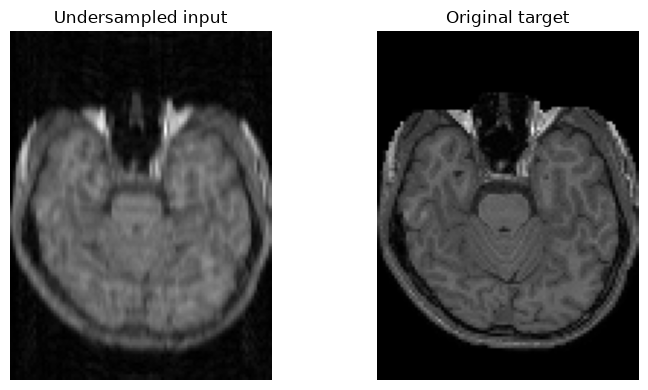

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(sample["input"][0], cmap="gray")
axes[0].set_title("Undersampled input")
axes[0].axis("off")

axes[1].imshow(sample["target"][0], cmap="gray")
axes[1].set_title("Original target")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Create data loader

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

## Train

In [16]:
model_kwargs = {
    "in_channels": 1,
    "out_channels": 1,
    "base_channels": 16,
}

model = ResidualUNet(**model_kwargs)

train_config = TrainConfig(
    epochs=10,
    learning_rate=1e-3,
    checkpoint_path="checkpoints/axial_r30_best.pt",
    seed=42,
    device=None,
)

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    train_config=train_config,
    model_kwargs=model_kwargs,
)

Training on device: cpu
Epoch 001/010 | train=0.118918 | val=0.051949 *
Epoch 002/010 | train=0.046868 | val=0.050334 *
Epoch 003/010 | train=0.042300 | val=0.042067 *
Epoch 004/010 | train=0.041866 | val=0.044480
Epoch 005/010 | train=0.042009 | val=0.041939 *
Epoch 006/010 | train=0.039884 | val=0.036642 *
Epoch 007/010 | train=0.039248 | val=0.038182
Epoch 008/010 | train=0.038998 | val=0.037356
Epoch 009/010 | train=0.039082 | val=0.040292
Epoch 010/010 | train=0.038040 | val=0.035181 *


## load the model

In [17]:
loaded_model, checkpoint = load_checkpoint(
    checkpoint_path="checkpoints/axial_r30_best.pt",
    model_class=ResidualUNet,
)

print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["validation_loss"])

Best epoch: 10
Best validation loss: 0.035180847719311716


## Run inference

In [ ]:
test_sample = test_dataset[0]

prediction = predict_tensor(
    model=loaded_model,
    input_tensor=test_sample["input"],
)